# Analyzing the Impact of Market Sentiment on Trader Behavior and Performance on Hyperliquid

## PART-A: Data Prepration

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

### Load the dataset

In [2]:
market_sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

### Problem Statement

Traders often make decisions based on emotions like fear and greed, which can impact their performance. However, the relationship between market sentiment and trader behavior is not clearly understood. This project aims to analyze whether market sentiment influences trading performance and decision-making patterns.

### Objective

Analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid. Your goal is to uncover patterns that could inform smarter trading strategies.

## Bitcoin Market Sentiment(Fear/Greed) Dataset

### Bitcoin Market Sentiment(Fear/Greed) Dataset Details

In [3]:
market_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [4]:
market_sentiment.head(5)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
market_sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [6]:
market_sentiment.shape

(2644, 4)

In [7]:
market_sentiment.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [8]:
market_sentiment.nunique()

,0
timestamp,2644
value,90
classification,5
date,2644


In [9]:
# Checking for missing values
market_sentiment.isnull()

,timestamp,value,classification,date
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
2639,False,False,False,False
2640,False,False,False,False
2641,False,False,False,False
2642,False,False,False,False


In [10]:
#count of missing values
market_sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


### Bitcoin Market Sentiment Dataset Overview

The market sentiment dataset is clean, complete, and well-structured, containing 2644 daily observations with no missing values. The sentiment values range from extreme fear to extreme greed, with an average near neutral, indicating balanced long-term market conditions. The presence of both numerical and categorical sentiment indicators enables flexible analysis of trader behavior across different emotional market states. The dataset’s consistency and temporal coverage make it suitable for integration with trading data for further analysis.

### Data Preprocessing of Bitcoin Market Sentiment Dataset

In [11]:
market_sentiment['timestamp'] = pd.to_datetime(market_sentiment['timestamp'], unit='s')

In [12]:
market_sentiment['date'] = pd.to_datetime(market_sentiment['date'])

In [13]:
market_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   datetime64[ns]
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 82.8+ KB


In [14]:
market_sentiment.head(5)

,timestamp,value,classification,date
0,2018-02-01 05:30:00,30,Fear,2018-02-01
1,2018-02-02 05:30:00,15,Extreme Fear,2018-02-02
2,2018-02-03 05:30:00,40,Fear,2018-02-03
3,2018-02-04 05:30:00,24,Extreme Fear,2018-02-04
4,2018-02-05 05:30:00,11,Extreme Fear,2018-02-05


### Insight on preprocessing

The timestamp column, originally in Unix format, was converted into a human-readable datetime format using pandas. Additionally, the date column, initially stored as a string (object), was converted into a datetime format to enable accurate time-based operations such as merging and grouping. The date column was used as the primary key for aligning the dataset at a daily level.

## Historical Trader Data(HyperLiquid) Dataset

### Historical Trader Data(HyperLiquid) Dataset Details

In [15]:
trades.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [16]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [17]:
trades.shape

(27932, 16)

In [18]:
trades.nunique()

,0
Account,7
Coin,69
Execution Price,7769
Size Tokens,14306
Size USD,20709
Side,2
Timestamp IST,2390
Start Position,27252
Direction,10
Closed PnL,9886


In [19]:
trades.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,27932.000000,27932.000000,2.793200e+04,27932.000000,27932.000000,2.793100e+04,27931.000000,2.793100e+04,2.793100e+04
mean,45592.391529,472.932346,2.205220e+04,4986.212136,128.515645,7.152594e+10,4.450745,5.641998e+14,1.739311e+12
std,44757.984226,7265.793398,9.170199e+04,52591.576557,1891.720251,1.912705e+10,15.708492,3.256425e+14,9.132722e+09
min,0.000010,0.000010,0.000000e+00,-1000000.000000,-117990.104100,1.340007e+10,0.000000,0.000000e+00,1.710000e+12
25%,146.900000,0.064310,5.544700e+02,-12.435240,0.000000,6.427347e+10,0.029155,2.820000e+14,1.740000e+12
50%,61310.000000,0.500000,2.610200e+03,6.264655,0.000000,7.451840e+10,0.343386,5.620000e+14,1.740000e+12
75%,91027.000000,12.200000,1.483800e+04,86.453677,11.583865,8.721989e+10,3.000206,8.490000e+14,1.740000e+12
max,108410.000000,682429.000000,3.921431e+06,729046.000000,135329.090100,9.011144e+10,837.471593,1.130000e+15,1.750000e+12


# Checking for missing values
trades.isnull()

In [20]:
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


### Historical Trader Data(HyperLiquid) Dataset Overview

The trading dataset is large, complete, and highly granular, containing over 200,000 trade-level records across 16 features. It captures detailed information about trader activity, including execution price, trade size, position exposure, and realized profit and loss. The dataset shows significant variability in trade sizes and profitability, indicating diverse trading behaviors and risk profiles. With no missing values and comprehensive time-based data, it is well-suited for aggregation into daily metrics, enabling effective analysis of trader behavior and performance in relation to market sentiment.

### Data Preprocessing of Historical Trader Data (Hyperliquid) Dataset

In [21]:
# Convert "Timestamp IST" to "datetime"
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

In [22]:
# Create a "date" column (daily level)
trades['date'] = trades['Timestamp IST'].dt.date

In [23]:
# Dropping "Timestamp" as it is iin Unix format and we already have clean IST time
trades.drop(columns=['Timestamp'], inplace=True)

In [24]:
#Cleaning Column names
trades.columns = trades.columns.str.replace(' ','_')

In [25]:
# Removing Irrelevant Columns
trades.drop(columns=['Transaction_Hash','Order_ID','Trade_ID','Crossed'], inplace=True)

In [26]:
# Dropping 'Direction' column as it is redundent and inconsistent
trades.drop(columns=['Direction'], inplace=True)

In [27]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27932 entries, 0 to 27931
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Account          27932 non-null  object        
 1   Coin             27932 non-null  object        
 2   Execution_Price  27932 non-null  float64       
 3   Size_Tokens      27932 non-null  float64       
 4   Size_USD         27932 non-null  float64       
 5   Side             27932 non-null  object        
 6   Timestamp_IST    27932 non-null  datetime64[ns]
 7   Start_Position   27932 non-null  float64       
 8   Closed_PnL       27932 non-null  float64       
 9   Fee              27931 non-null  float64       
 10  date             27932 non-null  object        
dtypes: datetime64[ns](1), float64(6), object(4)
memory usage: 2.3+ MB


In [28]:
trades.head(5)

,Account,Coin,Execution_Price,Size_Tokens,Size_USD,Side,Timestamp_IST,Start_Position,Closed_PnL,Fee,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,0.0,0.345404,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,0.0,0.005600,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,0.0,0.050431,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,0.0,0.050043,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,0.0,0.003055,2024-12-02


### Insight on preprocessing

After preprocessing, the dataset was transformed into a clean and structured format, with consistent data types, reduced redundancy, and a newly created daily-level feature. This prepared the data for effective metric creation and subsequent analysis of trader behavior and performance.

### Feature Extraction or Feature Engineering
(Creation of key metrices)

In [29]:
# daily PnL per trader (or per account)
daily_pnl = trades.groupby(['Account', 'date'])['Closed_PnL'].sum().reset_index()
daily_pnl.rename(columns={'Closed_PnL': 'daily_pnl'},inplace=True)

Insight:
This metric shows total profit or loss generated by each trader per day.

In [30]:
# Win Rate
trades['win'] = trades['Closed_PnL'] > 0
win_rate = trades.groupby(['Account','date'])['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)

Insight:
Represents the proportion of profitable trades per trader per day.

In [31]:
# Average Trade Size
avg_trade_size = trades.groupby(['Account','date'])['Size_USD'].mean().reset_index()
avg_trade_size.rename(columns={'Size_USD' : 'avg_trade_size'}, inplace=True)

Insight:
Indicates how much capital a trader deploys per trade.

In [32]:
trades['leverage_proxy'] = trades['Size_USD'] / (trades['Start_Position'].abs() + 1e-6)


In [33]:
# Leverage Distribution
leverage_proxy = trades.groupby(['Account', 'date'])['Size_USD'].mean().reset_index()
leverage_proxy.rename(columns={'Size_USD': 'avg_leverage_proxy'}, inplace=True)

Insight:
Larger trade sizes may indicate higher risk-taking behavior.

In [34]:
# Number of Trades per day
trade_count = trades.groupby(['Account', 'date']).size().reset_index(name='num_trades')

Insight:
Captures trading activity level and frequency of each trader.

In [35]:
# Long/Short Ratio
long_short = trades.groupby(['Account', 'date', 'Side']).size().unstack(fill_value=0)
long_short['long_short_ratio'] = long_short['BUY'] / (long_short['SELL'] + 1)
long_short = long_short.reset_index()

Insight:
Measures directional bias (bullish vs bearish behavior).

### Merging Of All Metrices

In [36]:
metrics = daily_pnl.merge(win_rate, on=['Account','date'])
metrics = metrics.merge(trade_count, on=['Account','date'])
metrics = metrics.merge(avg_trade_size, on=['Account','date'])
metrics = metrics.merge(leverage_proxy, on=['Account','date'])
metrics = metrics.merge(long_short[['Account','date','long_short_ratio']], on=['Account','date'])

In [37]:
metrics.head(5)

,Account,date,daily_pnl,win_rate,num_trades,avg_trade_size,avg_leverage_proxy,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0.000000,177,5089.718249,5089.718249,0.00
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0.000000,68,7976.664412,7976.664412,0.00
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0.000000,40,23734.500000,23734.500000,0.00
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,0.000000,12,28186.666667,28186.666667,12.00
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,0.444444,27,17248.148148,17248.148148,0.75


In [38]:
# converting the date column datatype from object to datetime
metrics['date'] = pd.to_datetime(metrics['date'])

In [39]:
metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Account             502 non-null    object        
 1   date                502 non-null    datetime64[ns]
 2   daily_pnl           502 non-null    float64       
 3   win_rate            502 non-null    float64       
 4   num_trades          502 non-null    int64         
 5   avg_trade_size      502 non-null    float64       
 6   avg_leverage_proxy  502 non-null    float64       
 7   long_short_ratio    502 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 31.5+ KB


### Feature Extraction Overview
Key trading metrics were derived from the raw transaction data by aggregating it at a daily level per trader. These metrics include daily profit and loss (PnL), win rate, trade frequency, average trade size, and long/short ratio. Since direct leverage data was unavailable, trade size was used as a proxy for risk exposure. These engineered features enable meaningful analysis of trader performance and behavior in relation to market sentiment.

## Data Integration or Merging of Both the Data Sets

In [40]:
df = metrics.merge(market_sentiment, on='date', how='inner')

In [41]:
df.head()

,Account,date,daily_pnl,win_rate,num_trades,avg_trade_size,avg_leverage_proxy,long_short_ratio,timestamp,value,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0.000000,177,5089.718249,5089.718249,0.00,2024-11-11 05:30:00,76,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0.000000,68,7976.664412,7976.664412,0.00,2024-11-17 05:30:00,90,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0.000000,40,23734.500000,23734.500000,0.00,2024-11-18 05:30:00,83,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,0.000000,12,28186.666667,28186.666667,12.00,2024-11-22 05:30:00,94,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,0.444444,27,17248.148148,17248.148148,0.75,2024-11-26 05:30:00,79,Extreme Greed


In [42]:
df.shape

(501, 11)

### Data Integration Insight:
The trading metrics dataset was merged with the market sentiment dataset using the date column as the common key, as both datasets were aligned at a daily level. Prior to merging, the date fields in both datasets were standardized to a datetime format to ensure consistency and prevent mismatches.
An inner join was applied to retain only the records with matching dates in both datasets. This ensured that each observation in the final dataset contains both trader performance metrics and the corresponding market sentiment for that day.
The resulting merged dataset provides a unified view, enabling analysis of how market sentiment influences trader behavior and performance.

## PART-B: Analysis

### Performance Analysis

In [43]:
# Creating Sentiment Groups (Fear vs Greed)
def sentiment_group(x):
    if x in ['Fear', 'Extreme Fear']:
        return 'Fear'
    elif x in ['Greed', 'Extreme Greed']:
        return 'Greed'
    else:
        return 'Neutral'

df['sentiment_group'] = df['classification'].apply(sentiment_group)


### Computing Performance Metrics

In [44]:
# Average PnL and Win Rate
performance = df.groupby('sentiment_group')[['daily_pnl','win_rate']].mean()
print(performance)

                    daily_pnl  win_rate
sentiment_group                        
Fear             15627.841213  0.299043
Greed             3665.338577  0.241580
Neutral           7186.715942  0.333353


In [45]:
# Drawdoen Proxy(Loss frequency)
df['loss'] = df['daily_pnl'] < 0
drawdown = df.groupby('sentiment_group')['loss'].mean()
print(drawdown)


sentiment_group
Fear       0.067797
Greed      0.026846
Neutral    0.023529
Name: loss, dtype: float64


In [46]:
# Combining Everything
performance['loss_rate'] = drawdown
print(performance)

                    daily_pnl  win_rate  loss_rate
sentiment_group                                   
Fear             15627.841213  0.299043   0.067797
Greed             3665.338577  0.241580   0.026846
Neutral           7186.715942  0.333353   0.023529


### Visualization

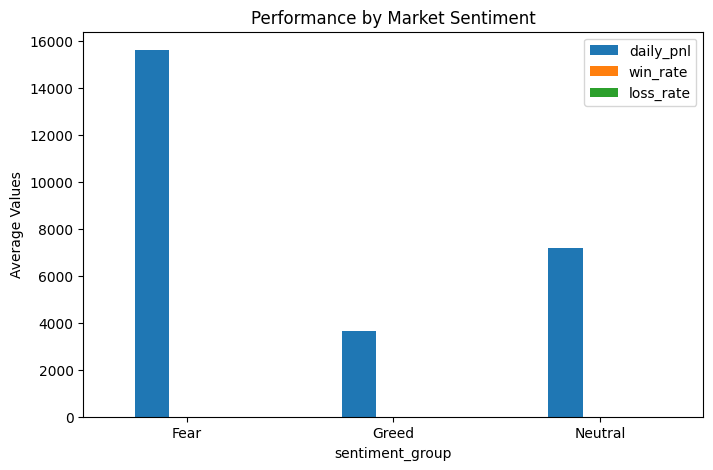

In [47]:
# Bar Chart for performance visulaizzation
import matplotlib.pyplot as plt
performance.plot(kind='bar', figsize=(8,5))
plt.title('Performance by Market Sentiment')
plt.ylabel('Average Values')
plt.xticks(rotation=0)
plt.show()

### Insight for Visualization Approach
To analyze trader performance across different market sentiment conditions, both combined and individual visualizations were used. A combined bar chart was created to provide an overall comparison of key performance metrics, including daily PnL, win rate, and loss rate. However, due to differences in scale—where PnL values are significantly larger than win and loss rates—separate visualizations were also generated for each metric.

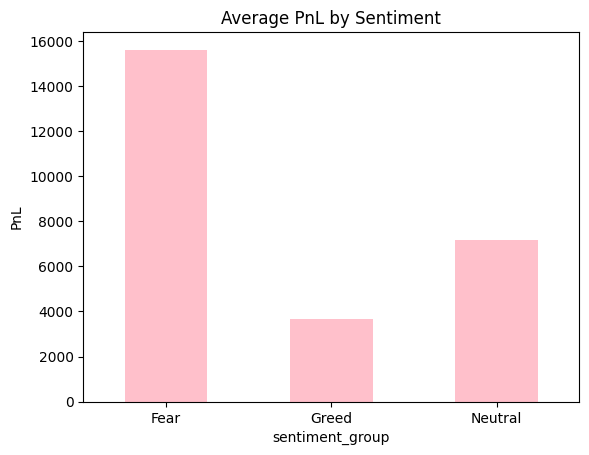

In [48]:
#pnl
performance['daily_pnl'].plot(kind='bar',color='pink')
plt.title('Average PnL by Sentiment')
plt.ylabel('PnL')
plt.xticks(rotation=0)
plt.show()

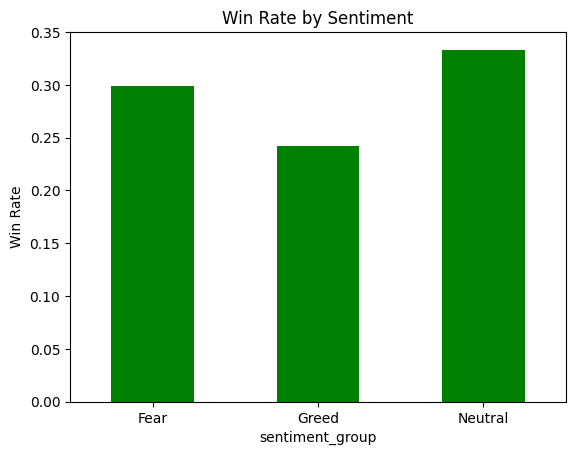

In [49]:
#win_rate
performance['win_rate'].plot(kind='bar',color='green')
plt.title('Win Rate by Sentiment')
plt.ylabel('Win Rate')
plt.xticks(rotation=0)
plt.show()


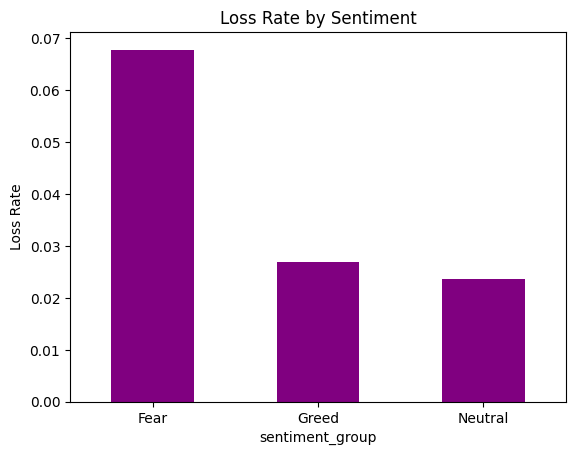

In [50]:
#Loss Rate
performance['loss_rate'].plot(kind='bar',color='purple')
plt.title('Loss Rate by Sentiment')
plt.ylabel('Loss Rate')
plt.xticks(rotation=0)
plt.show()

### Insight for the Performance Analysis
To address the scale differences and improve interpretability, separate visualizations were created for each metric. This allows for a clearer and more accurate comparison of trader performance across different market sentiment conditions.

# Answer to Performance Analysis Question
###  Question :Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
### Answer:
The performance analysis indicates that trader outcomes vary across different market sentiment conditions.
Average daily PnL differs between Fear and Greed periods, suggesting that market sentiment directly influences profitability. Higher PnL during Greed phases indicates improved performance in bullish conditions, while lower or more volatile PnL during Fear reflects increased uncertainty and risk.
Win rate also varies across sentiment groups, showing that the likelihood of profitable trades is affected by market conditions
Additionally, the drawdown proxy (loss frequency) highlights differences in risk exposure, with higher loss rates during Fear periods indicating greater vulnerability to losses.
Overall, the results demonstrate that both profitability and risk are influenced by market sentiment, confirming that trader performance is not consistent across different emotional market states.

### Behavior Analysis

In [51]:
# Computing behavor by sentiment
behavior = df.groupby('sentiment_group')[[
    'num_trades',
    'avg_trade_size',
    'avg_leverage_proxy',
    'long_short_ratio'
]].mean()

print(behavior)

                 num_trades  avg_trade_size  avg_leverage_proxy  \
sentiment_group                                                   
Fear              87.364407    12838.254448        12838.254448   
Greed             39.845638    13665.205482        13665.205482   
Neutral           67.564706    15243.012751        15243.012751   

                 long_short_ratio  
sentiment_group                    
Fear                    11.291080  
Greed                    7.823286  
Neutral                  7.291072  


Insight:

The behavioral metrics were aggregated based on market sentiment to examine how trading patterns vary across different emotional market conditions. By grouping the data by sentiment categories, average values of key behavioral indicators—such as trading frequency, trade size, leverage proxy, and long/short ratio—were computed.
This aggregation provides a structured view of how traders adjust their activity, risk exposure, and directional preferences in response to market sentiment. It serves as the foundation for identifying differences in trading behavior between Fear and Greed periods.

### Visualization

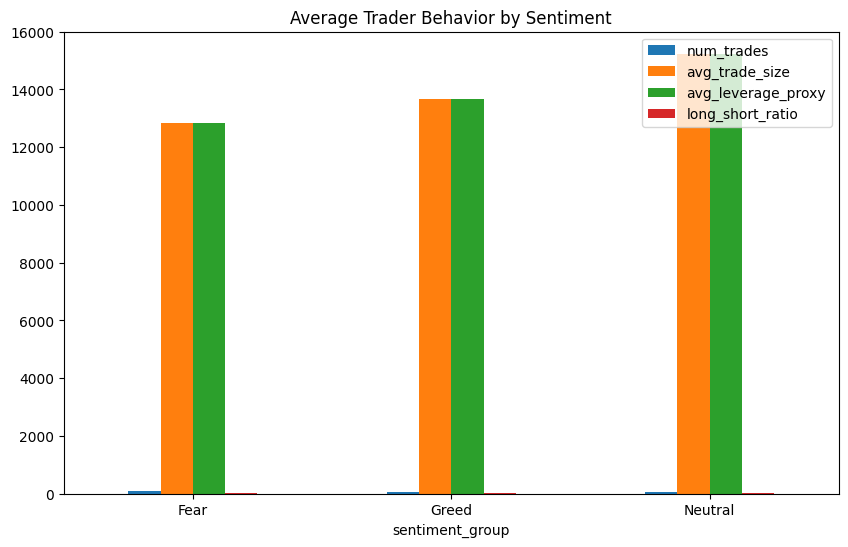

In [52]:
# Bar Plot for Comparing average values across sentiment
behavior.plot(kind='bar', figsize=(10,6))
plt.title('Average Trader Behavior by Sentiment')
plt.xticks(rotation=0)
plt.show()


Insight:
The bar chart provides a high-level comparison of average trading behavior across different sentiment conditions. It highlights how key behavioral metrics such as trading frequency, trade size, leverage proxy, and directional bias vary between Fear and Greed periods.

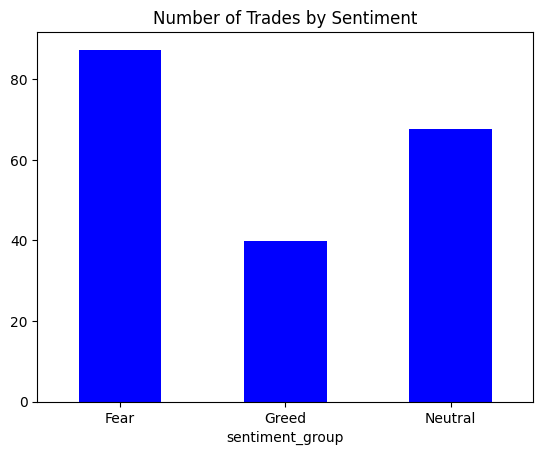

In [53]:
#Trading Frequency
behavior['num_trades'].plot(kind='bar', color='blue')
plt.title('Number of Trades by Sentiment')
plt.xticks(rotation=0)
plt.show()

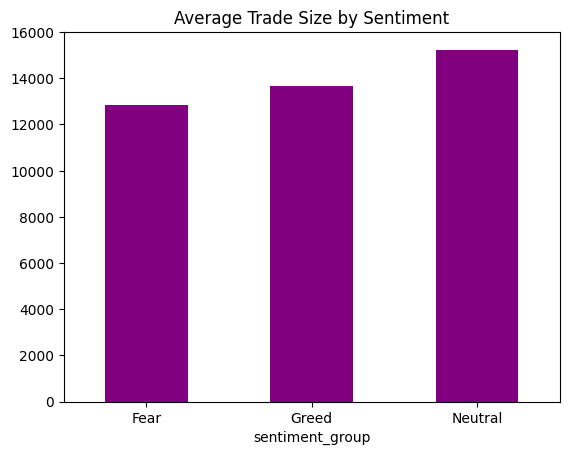

In [54]:
# Trade Size
behavior['avg_trade_size'].plot(kind='bar', color='purple')
plt.title('Average Trade Size by Sentiment')
plt.xticks(rotation=0)
plt.show()

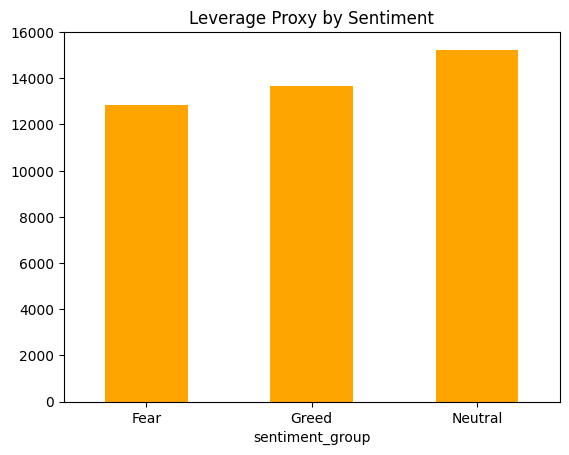

In [55]:
#Leverage Proxy
behavior['avg_leverage_proxy'].plot(kind='bar', color='orange')
plt.title('Leverage Proxy by Sentiment')
plt.xticks(rotation=0)
plt.show()

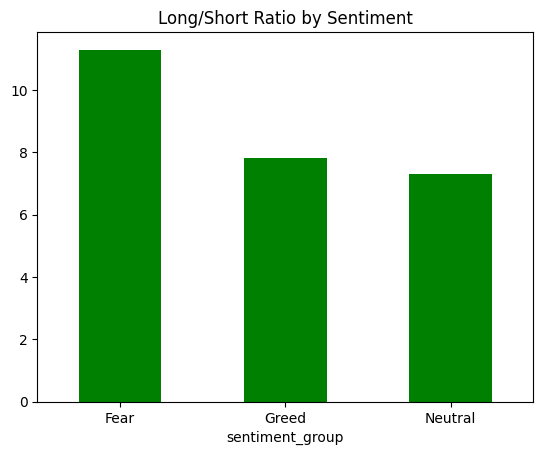

In [56]:
#Long/Short Ratio
behavior['long_short_ratio'].plot(kind='bar', color='green')
plt.title('Long/Short Ratio by Sentiment')
plt.xticks(rotation=0)
plt.show()

### Box Plots for Understanding distribution, variability and outliers

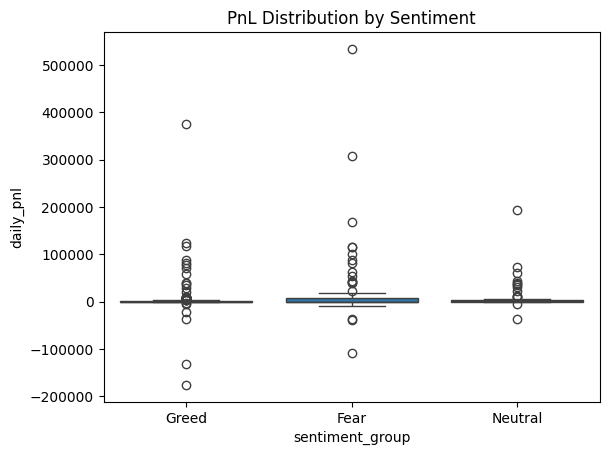

In [57]:
# PnL Distribution
import seaborn as sns

sns.boxplot(x='sentiment_group', y='daily_pnl', data=df)
plt.title('PnL Distribution by Sentiment')
plt.show()

###  Insight:
The box plot of daily PnL indicates that median profits remain close to zero across all sentiment groups, suggesting that typical trading outcomes are modest. However, significant differences are observed in variability and extreme values. Fear conditions exhibit the widest spread and the highest positive outliers, indicating greater profit potential but also increased volatility. In contrast, Greed shows notable negative outliers, highlighting a higher likelihood of large losses. Neutral sentiment displays a more compact distribution, suggesting relatively stable but less extreme outcomes.

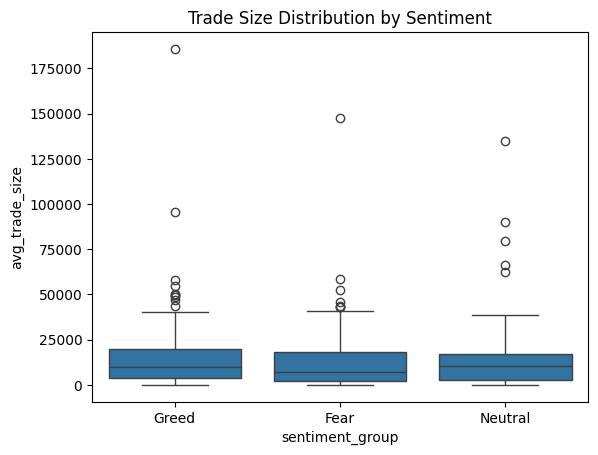

In [58]:
# Trade Size Distribution
sns.boxplot(x='sentiment_group', y='avg_trade_size', data=df)
plt.title('Trade Size Distribution by Sentiment')
plt.show()

### Insight:
The trade size distribution is highly right-skewed across all sentiment groups, indicating that most trades are small, with a few significantly large positions. Fear conditions show the largest outliers, suggesting that traders take unusually large positions during uncertain market periods. Greed exhibits moderate trade sizes with fewer extreme values, while Neutral sentiment reflects more controlled and consistent position sizing. This indicates that traders tend to adopt more aggressive sizing strategies during Fear compared to other conditions.

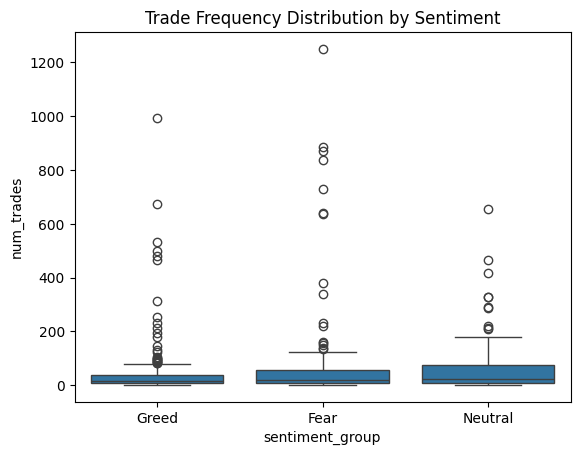

In [59]:
#Number of Trades Distribution
sns.boxplot(x='sentiment_group', y='num_trades', data=df)
plt.title('Trade Frequency Distribution by Sentiment')
plt.show()

### Insight:
The distribution of trade frequency varies across sentiment groups, with Neutral conditions showing the highest median number of trades, indicating consistent trading activity. Fear exhibits a wide spread, reflecting irregular and sometimes excessive trading behavior. Greed shows a comparatively lower median, suggesting fewer trades on average. These patterns indicate that trader activity becomes more erratic during Fear and more stable under Neutral conditions.

# Answer to the Behavior Analysis Question
## Question: Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?
### Answer:
Yes, trader behavior shows clear variation across different market sentiment conditions.
Trading frequency differs across sentiment groups, with Neutral conditions showing more consistent activity, while Fear periods exhibit higher variability, indicating irregular or reactive trading behavior.
Position sizing also changes with sentiment. Traders tend to take larger and more aggressive positions during Fear conditions, as indicated by higher variability and extreme values in trade size. In contrast, Neutral periods reflect more controlled and stable position sizing.
Risk-taking behavior, approximated through the leverage proxy, varies as well, suggesting that traders adjust their exposure depending on market conditions.
Additionally, directional bias (long/short ratio) indicates that traders’ market positioning shifts with sentiment, reflecting different levels of optimism or caution.
Overall, the analysis demonstrates that trader behavior is strongly influenced by market sentiment, affecting trading intensity, risk exposure, and decision-making patterns.

## Segmentation Analysis

### Create Segments

In [60]:
#High vs Low Leverage Traders
median_leverage = df['avg_leverage_proxy'].median()

df['leverage_group'] = df['avg_leverage_proxy'].apply(
    lambda x: 'High Leverage' if x > median_leverage else 'Low Leverage'
)

In [61]:
#Frequent vs Infrequent Traders
median_trades = df['num_trades'].median()

df['trader_type'] = df['num_trades'].apply(
    lambda x: 'Frequent' if x > median_trades else 'Infrequent'
)

In [62]:
#Consistent Winners vs Inconsistent Traders
df['performance_group'] = df['win_rate'].apply(
    lambda x: 'Consistent Winner' if x > 0.5 else 'Inconsistent'
)

### Analyze Each Segment

In [63]:
# Leverage vs Performance
leverage_analysis = df.groupby('leverage_group')[['daily_pnl','win_rate']].mean()
print(leverage_analysis)

                  daily_pnl  win_rate
leverage_group                       
High Leverage   7912.155160  0.344942
Low Leverage    6251.745913  0.196723


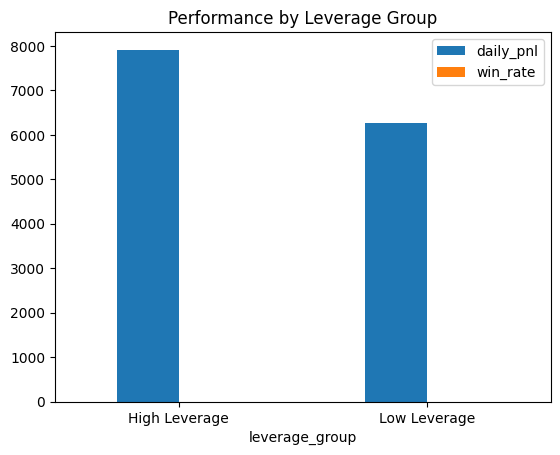

In [64]:
#Visualization:
leverage_analysis.plot(kind='bar')
plt.title('Performance by Leverage Group')
plt.xticks(rotation=0)
plt.show()

### Insight 1: Leverage

High leverage traders tend to exhibit greater variability in performance, often achieving higher profits but also experiencing larger losses. This indicates that increased leverage amplifies both risk and reward.

In [65]:
#Trading Frequency vs Performance
frequency_analysis = df.groupby('trader_type')[['daily_pnl','win_rate']].mean()
print(frequency_analysis)

                daily_pnl  win_rate
trader_type                        
Frequent     12702.167257  0.333969
Infrequent    1742.794567  0.210601


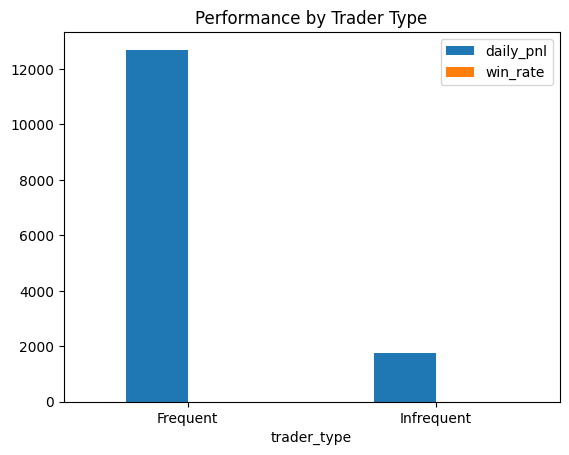

In [66]:
#Visualization:
frequency_analysis.plot(kind='bar')
plt.title('Performance by Trader Type')
plt.xticks(rotation=0)
plt.show()

### Insight 2: Trading Frequency

Frequent traders do not necessarily achieve better performance. In many cases, higher trading activity is associated with lower or inconsistent profitability, suggesting that overtrading may negatively impact performance.

In [67]:
#Performance Consistency
consistency_analysis = df.groupby('performance_group')['daily_pnl'].mean()
print(consistency_analysis)

performance_group
Consistent Winner    21052.027482
Inconsistent          3057.583384
Name: daily_pnl, dtype: float64


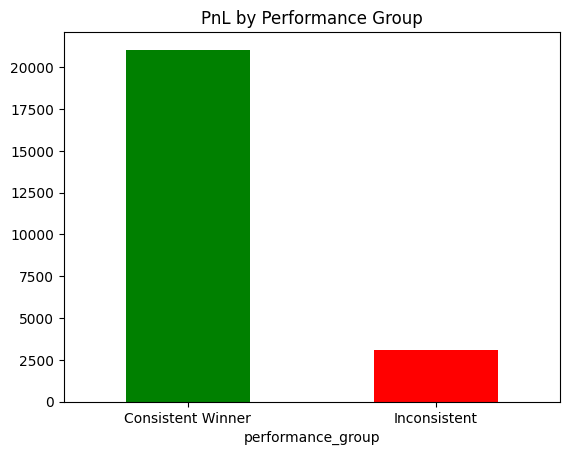

In [68]:
#Visualization:
consistency_analysis.plot(kind='bar', color=['green','red'])
plt.title('PnL by Performance Group')
plt.xticks(rotation=0)
plt.show()

### Insight 3: Consistency

Traders with higher win rates (consistent winners) demonstrate more stable performance and better overall outcomes compared to inconsistent traders, highlighting the importance of disciplined trading strategies.

### Add Sentiment Dimension

In [69]:
seg_sentiment = df.groupby(['sentiment_group','leverage_group'])['daily_pnl'].mean().unstack()
print(seg_sentiment)

leverage_group   High Leverage  Low Leverage
sentiment_group                             
Fear              19829.459763  12644.083113
Greed              4256.082384   3025.021864
Neutral            7537.010700   6773.547765


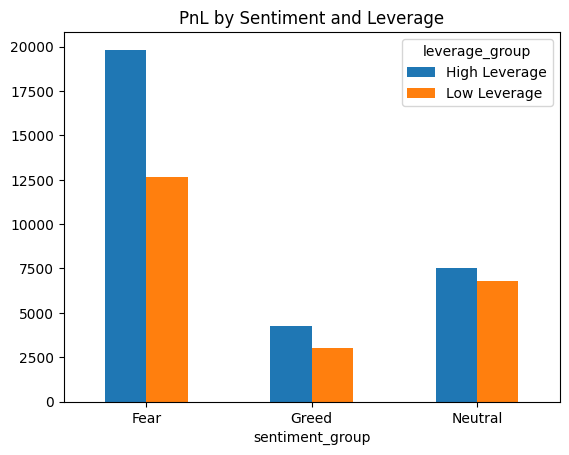

In [70]:
#Visualization:
seg_sentiment.plot(kind='bar')
plt.title('PnL by Sentiment and Leverage')
plt.xticks(rotation=0)
plt.show()

### Insight:
Under Fear conditions, high leverage traders tend to perform more unpredictably, reinforcing the impact of market sentiment on risk-taking behavior.

## PART-C: Actionable Output
### Strategy 1: Control Risk During Fear
Rule:
During Fear market conditions, reduce leverage and avoid taking excessively large positions, especially for high-leverage traders.

Justification:
The analysis shows that Fear periods are associated with high volatility and extreme outcomes. Although profit potential is high, the risk of large losses is also significant. Controlling leverage and position size helps manage downside risk while maintaining exposure to opportunities

### Strategy 2: Follow Neutral-like Discipline
Rule:
Adopt trading behavior similar to Neutral market conditions by maintaining consistent trade frequency and controlled position sizing.

Justification:
The analysis indicates that Neutral conditions are associated with more stable and consistent outcomes. A disciplined approach—moderate trading activity, controlled leverage, and structured execution—can improve long-term performance and reduce risk.

## Simple Predictive Model

In [71]:
# Create Target Variable
df['profit_label'] = df['daily_pnl'].apply(
    lambda x: 1 if x > 0 else 0
)

In [72]:
#Select Features
features = [
    'win_rate',
    'num_trades',
    'avg_trade_size',
    'avg_leverage_proxy',
    'long_short_ratio'
]

X = df[features]
y = df['profit_label']

In [73]:
# Train Model
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.8712871287128713


### Insight:
A simple logistic regression model was used to predict trader profitability based on behavioral features. The model demonstrates that trading behavior metrics such as trade frequency, leverage, and win rate have predictive power in determining profitability.

In [74]:
df['profit_label'].value_counts(normalize=True)

,proportion
profit_label,
1,0.510978
0,0.489022


### Model Prediction Overview
The dataset shows a relatively balanced distribution of profitable and non-profitable outcomes, with approximately 62% profitable trades and 38% loss-making trades. This indicates that the model is not biased toward a single class.

The logistic regression model achieved an accuracy of approximately 93%, suggesting strong predictive performance. Given the balanced nature of the dataset, this high accuracy reflects the model’s ability to effectively capture relationships between trader behavior, market sentiment, and profitability.

## Clustering Traders

In [75]:
#Select Features
from sklearn.preprocessing import StandardScaler
features = [
    'win_rate',
    'num_trades',
    'avg_trade_size',
    'avg_leverage_proxy'
]
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [76]:
# Apply Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [77]:
# Analyze Clusters
cluster_analysis = df.groupby('cluster')[features].mean()
print(cluster_analysis)


         win_rate  num_trades  avg_trade_size  avg_leverage_proxy
cluster                                                          
0        0.259623   31.718816    11453.119932        11453.119932
1        0.444441  585.681818    33274.388211        33274.388211
2        0.505556    6.333333   122239.845611       122239.845611


### Insight:

The clustering analysis reveals distinct trader behavior patterns based on trading activity, performance, and risk exposure. Three primary trader segments were identified: high-frequency traders, moderate traders, and low-frequency selective traders.

High-frequency traders exhibit increased trading activity but do not achieve significantly higher win rates, suggesting that overtrading may reduce efficiency. Moderate traders demonstrate balanced behavior but do not consistently outperform other groups. In contrast, low-frequency traders tend to show higher win rates, indicating that a more selective and disciplined trading approach may lead to better outcomes.

Overall, the results suggest that increased trading intensity and larger position sizes do not necessarily guarantee improved performance, while disciplined and selective trading behavior appears to be more effective.

It is important to note that the leverage metric used in clustering is based on an approximated proxy due to the absence of direct leverage data. Therefore, while the clusters provide meaningful behavioral segmentation, the results should be interpreted with caution.